In [1]:
import joblib
import numpy as np

X_train = joblib.load("../features/X_train.pkl")
X_val = joblib.load("../features/X_val.pkl")

y_train = joblib.load("../features/y_train.pkl")
y_val = joblib.load("../features/y_val.pkl")

X_test = joblib.load("../features/X_test.pkl")
y_test = joblib.load("../features/y_test.pkl")

# Combine train + val for CV tuning
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

In [2]:
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def svm_objective(trial):

    params = {
        "C": trial.suggest_float("C", 0.01, 100, log=True),
        "gamma": trial.suggest_float("gamma", 1e-4, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "poly"]),
        "class_weight": "balanced",
        "probability": True,
        "random_state": 42
    }

    model = SVC(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_full,
        y_train_full,
        cv=cv,
        scoring="average_precision",  # better for rare events
        n_jobs=-1,
        error_score=0
    )

    return scores.mean()

In [5]:
study_svm = optuna.create_study(direction="maximize")

study_svm.optimize(svm_objective, n_trials=500)

[I 2026-04-28 19:37:34,791] A new study created in memory with name: no-name-dbefe000-58be-4cac-9e4e-6ff37210de3c
[I 2026-04-28 19:39:08,946] Trial 0 finished with value: 0.17851331214448124 and parameters: {'C': 0.11227655277398263, 'gamma': 0.009276284382221184, 'kernel': 'poly'}. Best is trial 0 with value: 0.17851331214448124.
[I 2026-04-28 19:39:37,236] Trial 1 finished with value: 0.2859507643667607 and parameters: {'C': 9.627583319986089, 'gamma': 0.015872718502862777, 'kernel': 'rbf'}. Best is trial 1 with value: 0.2859507643667607.
[I 2026-04-28 19:41:48,713] Trial 2 finished with value: 0.18159154456790252 and parameters: {'C': 59.18118131065626, 'gamma': 0.001205815940317486, 'kernel': 'poly'}. Best is trial 1 with value: 0.2859507643667607.
[I 2026-04-28 19:42:24,618] Trial 3 finished with value: 0.2747241731221548 and parameters: {'C': 42.43199929576999, 'gamma': 0.03717535868764957, 'kernel': 'poly'}. Best is trial 1 with value: 0.2859507643667607.
[I 2026-04-28 19:43:01,

In [6]:
print("Best trial:")
print(study_svm.best_trial.params)
print("Best score:", study_svm.best_value)

Best trial:
{'C': 1.4125149787037912, 'gamma': 0.07745329275533004, 'kernel': 'rbf'}
Best score: 0.29745954278103887


In [7]:
best_svm = SVC(
    **study_svm.best_trial.params,
    class_weight="balanced",
    probability=True,
    random_state=42
)

best_svm.fit(X_train_full, y_train_full);

In [8]:
val_probs = best_svm.predict_proba(X_val)[:,1]

c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [9]:
thresholds = np.linspace(0.05,0.95,50)

results = []

for t in thresholds:
    
    preds = (val_probs >= t).astype(int)
    
    precision = precision_score(y_val,preds)
    recall = recall_score(y_val,preds)
    f1 = f1_score(y_val,preds)
    
    results.append((t,precision,recall,f1))

results = np.array(results)

c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


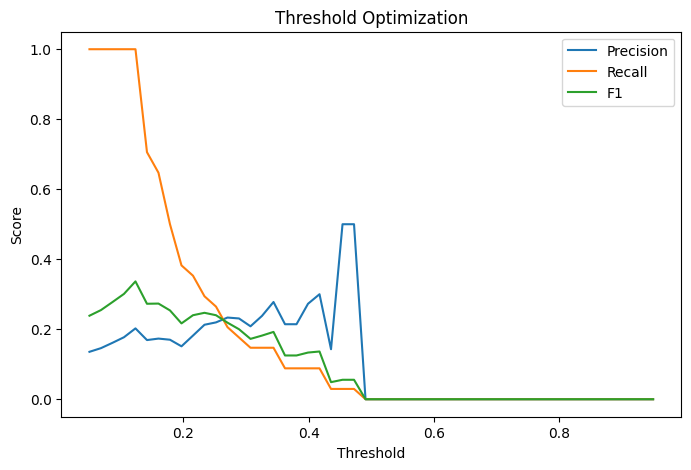

In [10]:
plt.figure(figsize=(8,5))

plt.plot(results[:,0],results[:,1],label="Precision")
plt.plot(results[:,0],results[:,2],label="Recall")
plt.plot(results[:,0],results[:,3],label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.show()

In [11]:
best_index = np.argmax(results[:,3])
best_threshold = results[best_index,0]

print("Best Threshold:",best_threshold)
print("Best F1:",results[best_index,3])

Best Threshold: 0.12346938775510204
Best F1: 0.33663366336633666


In [12]:
best_threshold = float(best_threshold)

val_preds = (val_probs >= best_threshold).astype(int)

In [13]:
print("Accuracy:", accuracy_score(y_val,val_preds))
print("Precision:", precision_score(y_val,val_preds))
print("Recall:", recall_score(y_val,val_preds))
print("F1:", f1_score(y_val,val_preds))
print("ROC-AUC:", roc_auc_score(y_val,val_probs))

Accuracy: 0.9818820984315847
Precision: 0.20238095238095238
Recall: 1.0
F1: 0.33663366336633666
ROC-AUC: 0.9898964475765857


In [14]:
print(classification_report(y_val,val_preds))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      7362
           1       0.20      1.00      0.34        34

    accuracy                           0.98      7396
   macro avg       0.60      0.99      0.66      7396
weighted avg       1.00      0.98      0.99      7396



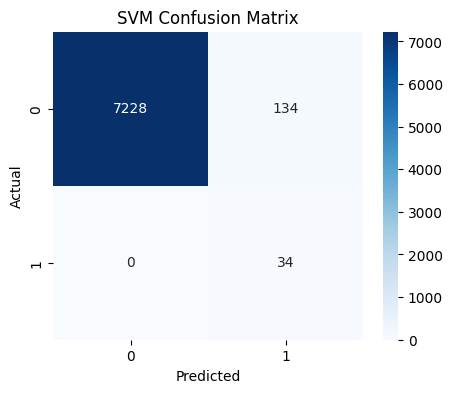

In [15]:
cm = confusion_matrix(y_val,val_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

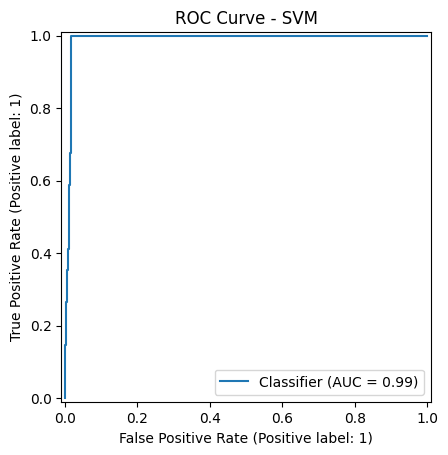

In [19]:
RocCurveDisplay.from_predictions(
    y_val,
    val_probs
)

plt.title("ROC Curve - SVM")

plt.show()

c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names

Text(0.5, 1.0, 'SVM Permutation Feature Importance')

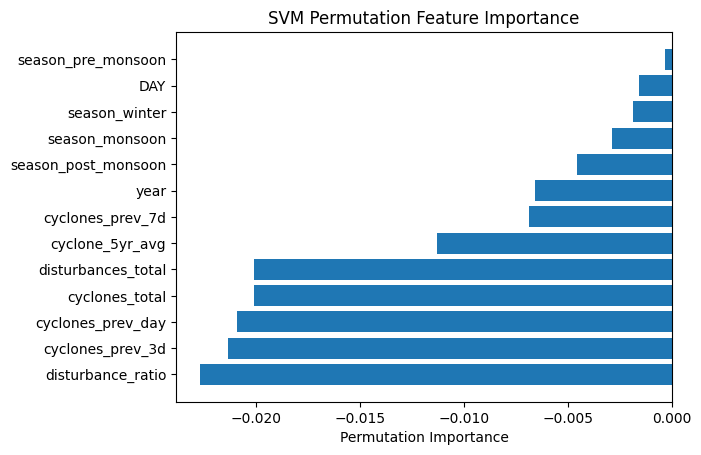

In [25]:
import pandas as pd
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(best_svm, X_test, y_test)
features = np.array(X_test.columns)
sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("SVM Permutation Feature Importance")


In [26]:
test_preds = best_svm.predict(X_test)
test_probs = best_svm.predict_proba(X_test)[:,1]

print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs))
print("TEST F1:", f1_score(y_test, test_preds))

c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


TEST ROC-AUC: 0.9892970297737822
TEST F1: 0.22580645161290322


In [27]:
joblib.dump(
    best_svm,
    "../models/svm_optuna_model.pkl"
)

['../models/svm_optuna_model.pkl']